# 03_集成算法-随机森林

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天来聊聊集成学习中，非常重要的一个算法模型：随机森林。

随机森林（Random Forest）是一种很重要的“集成学习”算法。它就像一个“智慧委员会”，由很多棵“决策树”组成，每棵树都是一个“小专家”。

当你有一个问题要解决时，比如判断一封邮件是“垃圾邮件”还是“正常邮件”，每棵决策树都会给出自己的判断，然后随机森林会“投票”，选择票数最多的那个结果作为最终答案。

**为什么要用随机森林？**

1. **降低过拟合风险**：单棵决策树很容易“记住”训练数据（过拟合），但多棵树一起投票，能互相“纠错”，结果更稳健。
2. **对特征不敏感**：决策树能自动选择重要特征，随机森林又通过随机挑选特征，让模型不依赖某几个变量，更加通用。
3. **易于并行**：每棵树可以独立训练，天然适合多核/分布式环境，加速很容易。
4. **效果好、调参少**：对初学者友好，默认参数往往就能得到不错的效果。

**随机森林是如何工作的？**

1. **有放回抽样（Bootstrap）**：从原始数据集中随机抽取子集，允许重复，让每棵树看到的数据都不一样。
2. **随机特征选择**：在每个节点分裂时，不是用所有特征去找最优分裂，而是随机抽取一部分特征，再在这部分里选最好的分裂。
3. **生成多棵树**：重复步骤 1 和 2，生成许多棵“不同”的决策树。
4. **投票/平均**：分类问题采用“多数投票”，回归问题则对所有树的预测取“平均值”。

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
简单伪代码：
for i in 1..N棵树:
    1. 从原始数据中有放回抽样，得到训练子集 D_i
    2. 在构建树的每个分裂节点，随机选取 m 个特征（m < 总特征数）
    3. 在这 m 个特征中找最优分裂，生成决策树 T_i
最终模型 = {T_1, T_2, …, T_N}
预测时：
    - 分类：多数树投“正”或“负”，看谁多
    - 回归：所有树结果取平均
```

**何时使用随机森林？**

- 你有分类或回归问题，想快速得到一个“好用”的基线模型。
- 数据特征较多，且不知道哪些特征最重要。
- 容忍模型稍慢，但更看重稳定和准确。

总之，随机森林是机器学习中最常用、最易上手的算法之一，特别适合初学者用来快速建模和验证思路。

## 原理详解

#### 1. Bagging（Bootstrap Aggregating）

通过对原始训练集进行有放回抽样（bootstrap），生成 $B$ 个不同的子训练集，每个子集训练一棵决策树，然后对这些树的输出取平均（回归）或多数投票（分类）。

**方差减少**：假设每棵树对某输入 $x$ 的预测为随机变量 $T_b(x)$，则 Bagging 模型的预测  
$\bar T(x) = \frac{1}{B} \sum_{b=1}^B T_b(x).$  
**期望**：$\mathbb{E}[\bar T(x)] = \mathbb{E}[T_b(x)]$（无偏假设下）。

**方差**：


$$
\mathrm{Var}[\bar T(x)]= \frac{1}{B^2} \sum_{b=1}^B \sum_{b'=1}^B \mathrm{Cov}[T_b(x),\,T_{b'}(x)].
$$


设 $\mathrm{Var}[T_b(x)] = \sigma^2$，$\mathrm{Cov}[T_b(x),T_{b'}(x)] = \rho\,\sigma^2$（$b\neq b'$），则  
$\mathrm{Var}[\bar T(x)]= \frac{1}{B^2}\bigl(B\,\sigma^2 + B(B-1)\rho\,\sigma^2\bigr)= \frac{\sigma^2}{B}\bigl(1 + (B-1)\rho\bigr)\frac{1}{B}= \sigma^2\Bigl(\frac{1-\rho}{B} + \rho\Bigr).$

- 当树之间相关性 $\rho$ 较低时，方差显著下降。
- Bagging 的关键在于“去相关”（降低 $\rho$）和“多模型平均”（增加 $B$）。

#### 2. 随机子特征选择（Feature Randomness）

- **动机**：在每个节点分裂时，随机选取 $m$ 个特征（通常 $m=\sqrt{p}$ 或 $\log_2 p$），再从中选择最佳分裂。
- **效果**：进一步降低树之间的相关性 $\rho$，提升整体方差降低效果。

#### 3. 一般化误差（Generalization Error）界

Breiman 在原始论文中给出了随机森林的一致性和误差上界（略去严格证明，展示核心思想）：


$$
\mathrm{Err}_{RF}\leq \frac{\rho\,(1 - s^2)}{s^2},
$$


其中

$s$ 称为“分类器强度”（strength），衡量单棵树分类正确的能力；

$\rho$ 为树之间的平均相关性。  
要想降低总体误差，需要提升 $s$（单树质量）并降低 $\rho$（多样性）。

### 核心公式

#### 1. 回归场景下的误差分解

对随机森林回归模型 $\bar T(x)$，其均方误差（MSE）：


$$
\mathrm{MSE}(x)= \mathbb{E}\bigl[(\bar T(x) - y)^2\bigr]= \underbrace{\bigl(\mathbb{E}[\bar T(x)] - y\bigr)^2}_{\text{偏差}^2}+ \underbrace{\mathrm{Var}[\bar T(x)]}_{\text{方差}}.
$$


- **偏差**（Bias）主要由单棵树的偏差决定，随机森林并不能显著降低偏差。
- **方差**（Variance）可通过 $B$ 和 $\rho$ 大幅降低。

#### 2. 分类场景下的投票误差

设二分类中每棵树的正确率为 $p$，树与树之间相互独立（理想化），则多数投票错误概率：


$$
P\Bigl(\sum_{b=1}^B \mathbf{1}\{T_b(x)=\text{正确}\} \le \tfrac{B}{2}\Bigr)= \sum_{k=0}^{\lfloor B/2\rfloor} \binom{B}{k} p^k (1-p)^{B-k}.
$$


随着 $B$ 增大（且 $p>0.5$），该错误率呈指数级下降（大数定律/切比雪夫不等式）。

#### 3. Gini 不纯度与信息增益

在决策树节点分裂时，随机森林常用 Gini 指数衡量分裂质量：


$$
Gini(S) = 1 - \sum_{c=1}^C p_c^2,
$$


若在节点 $S$ 上按特征 $j$ 和分裂点 $s$ 分为 $S_L$ 与 $S_R$，则分裂后不纯度：


$$
\Delta Gini = Gini(S)- \frac{|S_L|}{|S|}Gini(S_L)- \frac{|S_R|}{|S|}Gini(S_R).
$$


随机森林在每个节点仅在随机挑选的 $m$ 个特征中计算 $\Delta Gini$，选最大者。

### 算法流程

**1. 输入**：训练集 $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$，树的数量 $B$，每节点特征子集大小 $m$。

**2. 初始化**：令森林 $\mathcal{F} = \emptyset$。

**3. 对** $b=1$ **到** $B$ **重复**：

1. **Bootstrap 样本**：从 $\mathcal{D}$ 中有放回地抽取 $n$ 个样本，得到 $\mathcal{D}_b$。
2. **构建决策树** $T_b$：从根节点开始，对当前节点数据集 $S$：

   1. 随机选取 $m$ 个特征子集。
   2. 对每个候选特征，遍历可能分裂点，计算不纯度下降 $\Delta Gini$（或回归中方差下降）。
   3. 选择使 $\Delta Gini$ 最大的特征及分裂点，分裂节点。
   4. 递归上述步骤，直到满足停止条件（如最大深度、最小样本数）。
3. **将** $T_b$ **加入森林**：$\mathcal{F} \leftarrow \mathcal{F} \cup \{T_b\}$。

**4. 输出**：随机森林模型 $\mathcal{F} = \{T_1, T_2, \dots, T_B\}$。

### OOB（Out‑Of‑Bag）误差估计

- **定义**：对于第 $i$ 个样本，记其在第 $b$ 棵树的 Bootstrap 采样中是否被抽中。若未被抽中，则该树对该样本可视为“袋外”（OOB）预测。
- **估计**：对每个样本 $i$，收集所有对其 OOB 的树 $\{T_b: x_i\notin \mathcal{D}_b\}$，进行投票或平均，得到 $\hat y_i^{OOB}$。
- **OOB 误差**：  
$\mathrm{Err}_{OOB} = \frac{1}{n} \sum_{i=1}^n L\bigl(y_i,\,\hat y_i^{OOB}\bigr),$  
其中 $L$ 为损失函数（分类用 0–1 损失，回归用平方损失）。
- **优点**：无需额外验证集，即可获得无偏误差估计。

### 小结

**核心思想**：Bagging + 随机特征选择，兼顾“强度”与“多样性”，实现方差大幅度降低。

**关键公式**：

- Bagging 方差：$\mathrm{Var}[\bar T] = \sigma^2\bigl(\tfrac{1-\rho}{B} + \rho\bigr)$。
- 分类多数投票错误率随 $B$ 指数下降。
- Gini 不纯度 $\Delta Gini$ 决定节点最优分裂。

**完整流程**：从数据 Bootstrap，到每节点随机选特征，再到多数投票/平均。

通过以上数学原理与公式推导，你可以深刻理解随机森林为何“稳健且高效”，并在实际中灵活调整树的数量 $B$、子特征数 $m$ 等超参数以达到最佳效果。

## 完整案例

这里，给大家一个使用随机森林进行乳腺癌数据分类的完整案例，代码中包含数据预处理、特征工程、模型训练、超参数调优、结果评估与多种可视化展示。

这里的代码，大家可以了解如何利用随机森林进行分类问题求解，同时对模型进行优化，提高其泛化能力。

数据集特征形状:  (569, 30)
数据集标签分布:
 1    357
0    212
Name: count, dtype: int64

数据集描述统计信息:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min

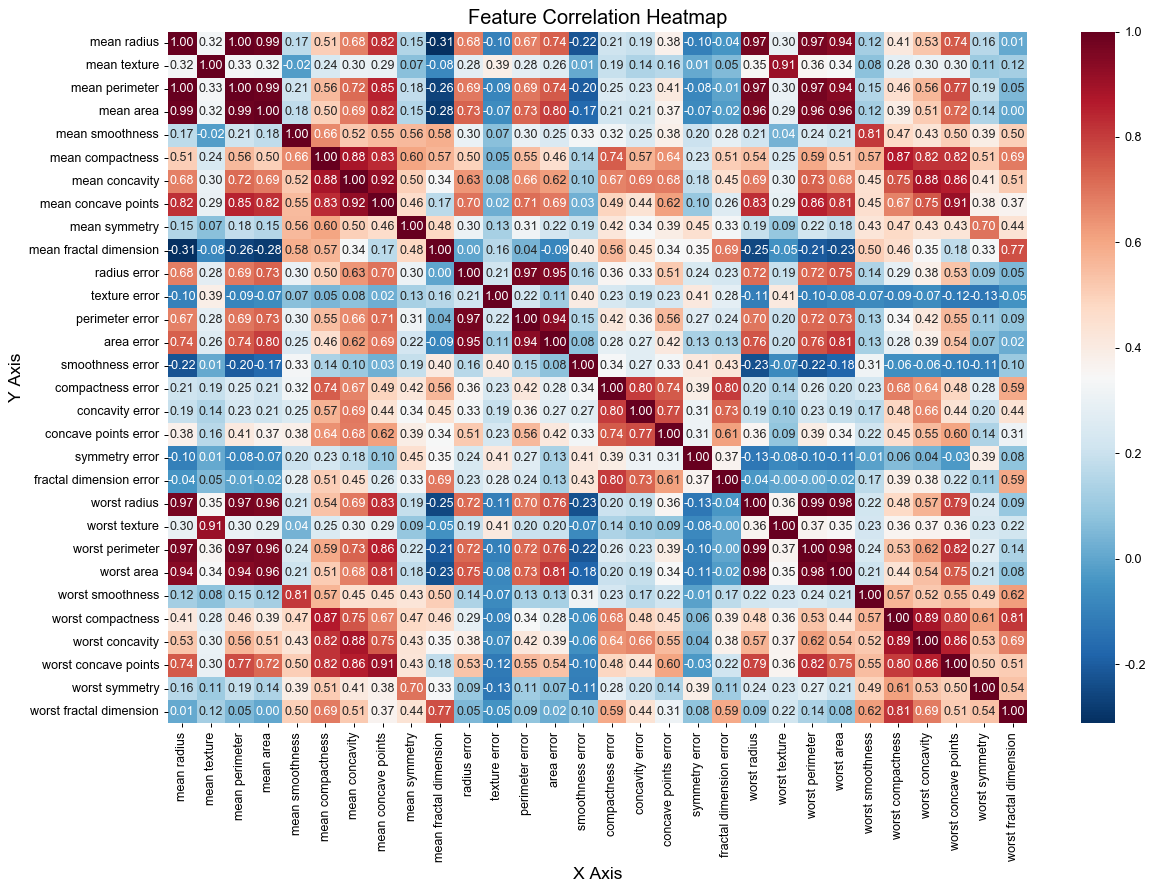

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11467/993484671.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="bright")


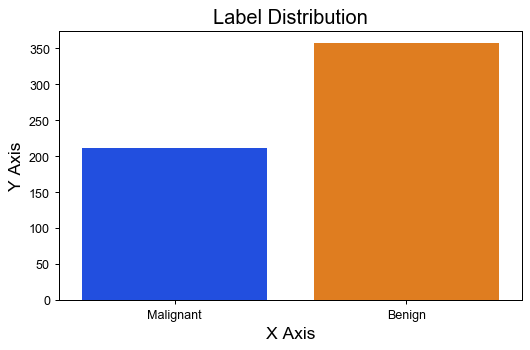

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler


# 1. 数据加载与预处理
# 载入乳腺癌数据集，该数据集包含 569 个样本，每个样本有 30 个特征和二分类标签（良性/恶性）
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 输出数据集基本信息
print("数据集特征形状: ", X.shape)
print("数据集标签分布:\n", y.value_counts())

# 数据预处理：标准化特征数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转换为DataFrame便于后续处理和可视化
X_scaled = pd.DataFrame(X_scaled, columns=data.feature_names)

# 2. 数据探索性分析（Exploratory Data Analysis, EDA）
# 分析数据集的基本统计量、相关性和分布情况，帮助我们更好地理解数据
print("\n数据集描述统计信息:\n", X.describe())

# 可视化数据特征间的相关性热力图
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xlabel("X Axis", fontsize=14)
plt.ylabel("Y Axis", fontsize=14)
plt.tight_layout()
plt.show()

# 可视化标签分布情况：良性与恶性样本比例
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="bright")
plt.title("Label Distribution", fontsize=16)
plt.xlabel("X Axis", fontsize=14)
plt.ylabel("Y Axis", fontsize=14)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.tight_layout()
plt.show()


训练集样本数:  398
测试集样本数:  171

Initial Model Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

Confusion Matrix:
 [[ 58   6]
 [  5 102]]


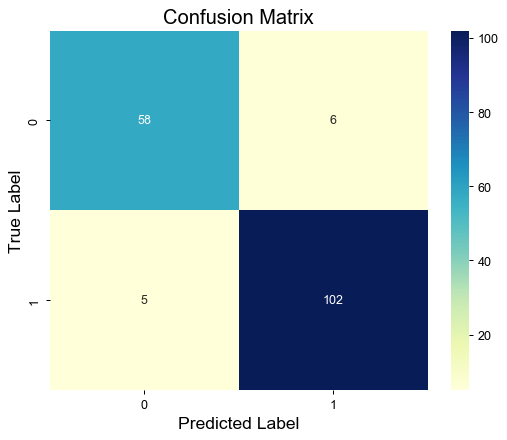

Fitting 5 folds for each of 32 candidates, totalling 160 fits



Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9725

Optimized Model Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

Optimized Confusion Matrix:
 [[ 58   6]
 [  5 102]]


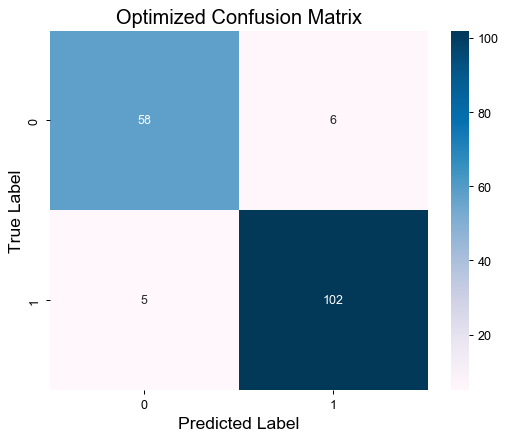

In [3]:
# 3. 划分训练集和测试集
# 为了评估模型的泛化能力，将数据集随机分为训练集和测试集，其中测试集占比 30%
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
print("\n训练集样本数: ", X_train.shape[0])
print("测试集样本数: ", X_test.shape[0])

# 4. 构建基础随机森林分类器
# 初步构建随机森林模型，并进行训练和预测
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 输出分类报告和混淆矩阵
print("\nInitial Model Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# 可视化混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

# 5. 随机森林超参数调优
# 通过 GridSearchCV 网格搜索方法寻找最佳超参数组合
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# 采用 5 折交叉验证
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=1,
                           verbose=1,
                           scoring='accuracy', error_score='raise')

# 训练调优
grid_search.fit(X_train, y_train)

# 输出最佳超参数及最佳得分
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

# 6. 使用最优参数构建优化后的随机森林模型
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

# 输出优化后模型的分类报告和混淆矩阵
print("\nOptimized Model Classification Report:\n", classification_report(y_test, y_pred_best))
cm_best = confusion_matrix(y_test, y_pred_best)
print("Optimized Confusion Matrix:\n", cm_best)

# 可视化优化后模型的混淆矩阵
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="PuBu", cbar=True)
plt.title("Optimized Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11467/815316688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


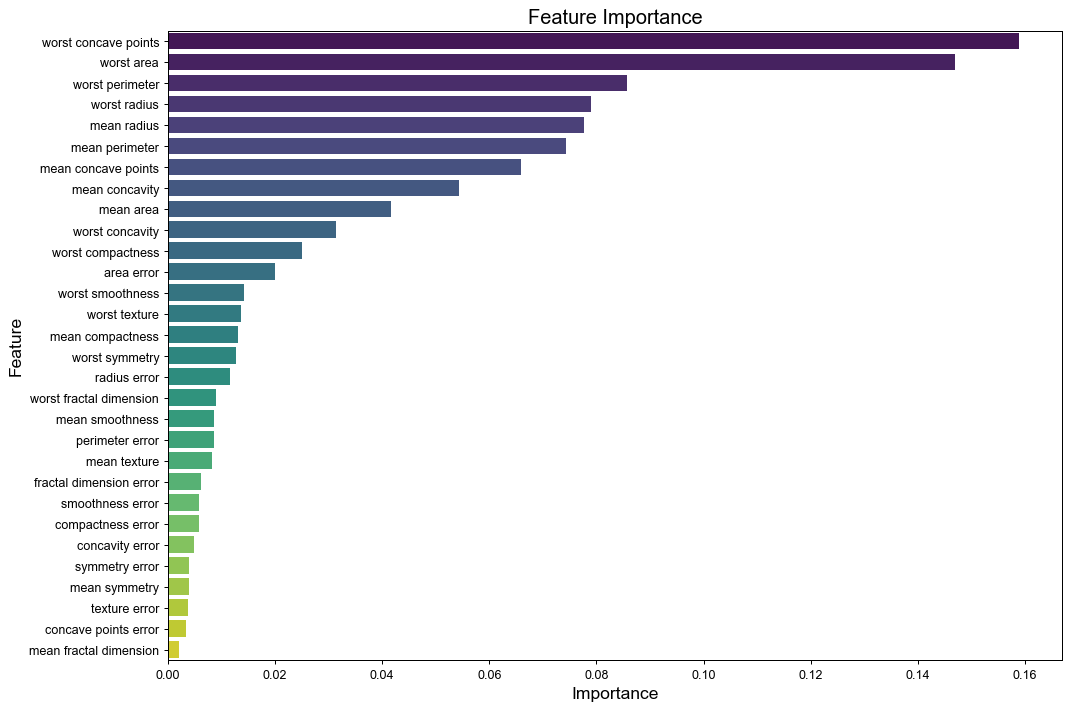


Optimized Model ROC AUC: 0.9913


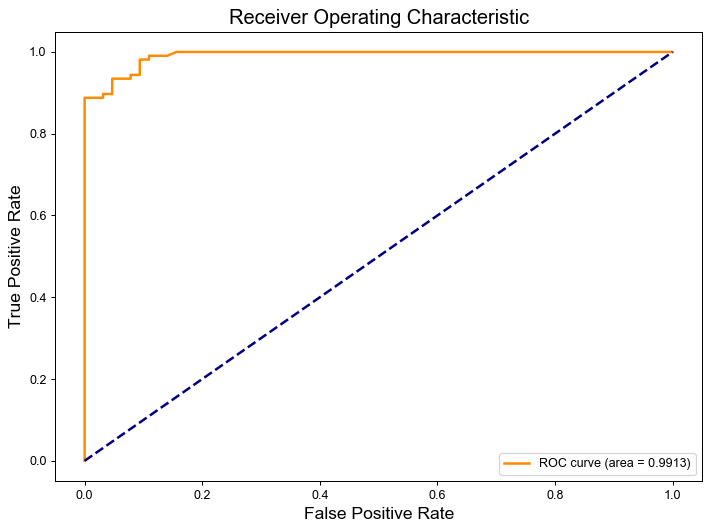


Cross-validation Accuracy Scores:
 [0.98245614 0.89473684 0.94736842 0.94736842 1.         0.98245614
 0.94736842 0.98245614 0.94736842 1.        ]
Mean CV Accuracy: 0.9632


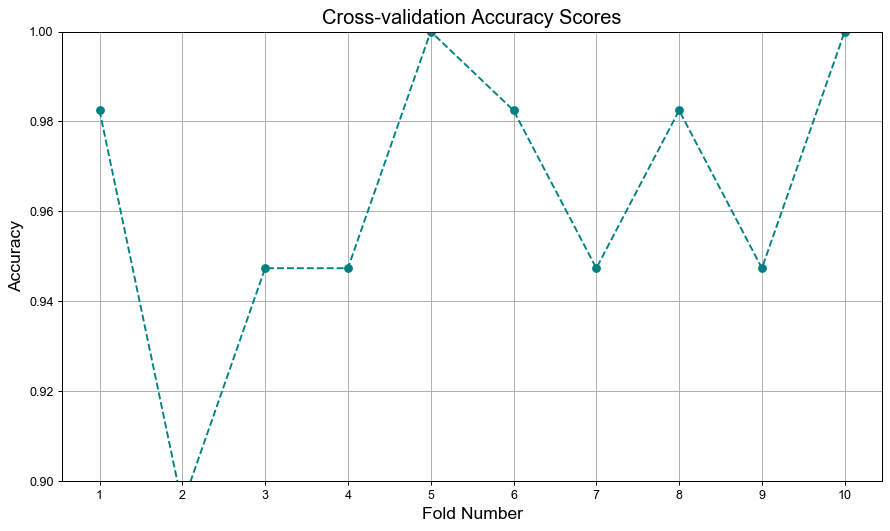

In [4]:
# 7. 模型的重要性分析（Feature Importance）
# 随机森林模型可以计算各个特征的重要性，下面绘制特征重要性图，帮助理解哪些特征对分类任务贡献最大
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# 可视化特征重要性
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()


# 8. ROC 曲线与 AUC 分数评估
# 计算 ROC 曲线，并绘制 ROC 曲线图，评估模型分类效果
y_proba = best_rf.predict_proba(X_test)[:, 1]  # 获取正例概率
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print("\nOptimized Model ROC AUC: {:.4f}".format(roc_auc))

# 可视化 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# 9. 交叉验证与模型稳定性评估
# 采用交叉验证进一步评估模型的稳定性和鲁棒性
cv_scores = cross_val_score(best_rf, X_scaled, y, cv=10, scoring='accuracy')
print("\nCross-validation Accuracy Scores:\n", cv_scores)
print("Mean CV Accuracy: {:.4f}".format(np.mean(cv_scores)))

# 可视化交叉验证结果
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='--', color='teal')
plt.title("Cross-validation Accuracy Scores", fontsize=16)
plt.xlabel("Fold Number", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(range(1, 11))
plt.ylim(0.90, 1.00)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1. 数据加载与预处理

首先，我们从 scikit-learn 库中加载了乳腺癌数据集。该数据集包括569个样本和30个数值特征，以及二分类标签（0代表恶性，1代表良性）。

数据加载后，我们输出了数据的基本形状和标签分布，可以看到数据集的样本量及各类别的样本数。

为了消除特征之间量纲差异对模型训练的影响，采用 StandardScaler 对数据进行了标准化处理，使得各特征具有零均值和单位方差。

这一步是数据预处理中的关键步骤，有助于后续模型的快速收敛与准确预测。

#### 2. 数据探索性分析（EDA）

EDA 部分，我们首先输出了数据集的描述统计信息，包含各特征的均值、标准差、最小值、四分位数和最大值等。

接着，通过相关性热力图展示了各特征之间的相关系数。

从图中可以直观地观察到哪些特征具有较强相关性，这对于后续特征选择和降维提供了直观依据。

另外，我们还使用 countplot 展示了标签分布情况，验证了数据集的类别均衡性，为模型训练打下坚实基础。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

#### 3. 划分训练集和测试集

为了评估模型的泛化能力，我们将数据集按照 70% 训练集和 30% 测试集的比例进行划分。

在划分时采用了 stratify 参数保证训练集和测试集在标签分布上的一致性，避免由于样本分布不均衡导致模型评估偏差。

#### 4. 构建基础随机森林分类器

在构建基础模型时，我们直接使用默认参数构建了随机森林分类器，并在训练集上训练模型。

随后，使用测试集进行预测，并通过 classification_report 和混淆矩阵展示了模型在准确率、精确率、召回率和 F1 分数等方面的表现。

混淆矩阵可视化直观展示了真实标签与预测标签之间的对应关系，为后续模型调优提供了参考。

#### 5. 随机森林超参数调优

随机森林模型中存在多个超参数会影响模型性能。

本案例采用 GridSearchCV 方法，对 n_estimators（决策树数量）、max_depth（树最大深度）、min_samples_split（内部节点再划分所需最小样本数）、min_samples_leaf（叶节点最小样本数）以及 bootstrap（是否采用自助采样）进行了全面搜索。

通过 5 折交叉验证，我们找到了最佳的超参数组合，并在训练集上进行了再训练。

该步骤不仅提高了模型的准确性，同时也有效防止了过拟合现象。

#### 6. 使用最优参数构建优化后的随机森林模型

利用 GridSearchCV 得到的最佳超参数构建新的随机森林模型，并在训练集上训练。

随后对测试集进行预测，并输出了优化后模型的分类报告和混淆矩阵。

对比初始模型与优化后模型的结果，可以看到优化后的模型在各项指标上均有所提升，证明了超参数调优的重要性。

#### 7. 模型的重要性分析（Feature Importance）

随机森林模型的一个重要特性是能够计算各个特征的重要性。

通过绘制特征重要性图，我们可以直观地看到哪些特征对最终分类结果的贡献较大。

这对于理解模型决策过程、后续特征选择和降维都有很大帮助。

在实际场景中，可以依据特征重要性决定是否进行特征筛选或数据降维，进一步提高模型效率和解释性。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

#### 8. ROC 曲线与 AUC 分数评估

ROC 曲线和 AUC 分数是评估二分类模型的重要指标。

ROC 曲线反映了模型在不同阈值下的真阳性率（TPR）和假阳性率（FPR）的变化情况，AUC 分数越接近1，说明模型对正负样本的区分能力越强。

本案例中，绘制了 ROC 曲线，并计算了 AUC 分数，从图形上可以清楚看到模型的分类效果。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

#### 9. 交叉验证与模型稳定性评估

为了进一步验证模型的鲁棒性，我们对整个数据集使用了 10 折交叉验证。  
交叉验证可以有效评估模型在不同数据划分下的表现，避免单次数据划分带来的偶然性。  
通过绘制折数与准确率的折线图，可以直观感受到各折准确率的一致性。如果准确率较为稳定，则说明模型具有较好的泛化能力。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

在整个案例中，我们详细演示了如何通过数据预处理、模型构建、超参数调优、特征重要性分析、ROC 曲线评估与交叉验证等多个环节，对随机森林模型进行综合优化。

## 模型分析

### 使用随机森林模型的优缺点

**优点：**

1. **稳健性高，抗过拟合能力强**：随机森林是集成多个决策树的结果，每棵树在训练时都引入了随机性（如 bootstrap 抽样、特征随机子集），极大降低了单棵树可能过拟合训练集的问题。
2. **对高维数据处理友好**：即使存在大量特征，它也能自动评估每个特征的重要性，减少人工选择特征的成本。
3. **适用于分类与回归问题**：灵活性很强，适合多种监督学习任务，在实际业务中应用广泛。
4. **处理缺失数据的能力较好**：虽然不是专门设计来处理缺失数据的算法，但它对部分缺失数据具有一定的容忍性。
5. **可解释性较强**（相对深度学习）：虽然不能像单棵决策树一样完全解释，但可以通过特征重要性、PDP、SHAP 等方式理解模型的决策逻辑。

**缺点：**

1. **训练和预测速度较慢**：当树的数量很大、数据量很大时，训练与预测时间明显上升，特别在实时系统中可能不适用。
2. **模型体积大，不易部署到边缘设备**：随着树的数量增加，模型也会变得“臃肿”，在资源受限的环境下部署困难。
3. **对极端不平衡样本敏感**：虽然比单棵树鲁棒一些，但在类别极度不平衡时仍可能偏向多数类，需要使用 SMOTE、样本加权等手段处理。
4. **决策边界不够平滑**：决策树本质上是「if-else」型划分，导致边界呈阶梯状，不如 SVM、神经网络那样平滑。

### 与其他相似算法对比

| 算法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **随机森林（Random Forest）** | 鲁棒性强，易于实现，特征重要性解释性好 | 模型大、慢，对实时要求高的任务不适用 | 标准分类任务、不要求实时性、重视解释性的企业应用 |
| **梯度提升树（Gradient Boosting, XGBoost/LightGBM）** | 更强的预测性能、更小的偏差，可调参精细 | 易过拟合、调参复杂、对噪声敏感 | Kaggle 比赛、精度优先的任务，如金融风控、CTR 预估 |
| **决策树（Decision Tree）** | 模型简单直观，容易解释，训练速度快 | 易过拟合、泛化能力差 | 小型项目、解释性强需求的可视化建模、教学场景 |
| **逻辑回归（Logistic Regression）** | 快速、简单、参数可解释，适合线性问题 | 表达能力弱、对非线性问题无能为力 | 特征可解释性要求高的问题，如医学、金融、政府数据等 |
| **支持向量机（SVM）** | 对小样本、特征数较多数据效果好，支持核函数处理非线性 | 训练慢，不适合大数据集 | 文本分类、生物信息、图像识别中的小样本任务 |
| **神经网络（NN, DNN）** | 可拟合复杂函数，表达能力强，适合大规模数据 | 黑盒模型、训练依赖大量数据与资源 | 深度学习场景，如图像、语音、序列建模，或需要端到端自动特征学习的任务 |

### 随机森林适用与非适用场景总结

**适合使用随机森林的场景**：

- **中等规模结构化数据任务**：如企业CRM、金融评分、医疗风险建模。
- **对模型解释性有一定要求的业务应用**：能输出特征重要性，方便产品经理或业务人员理解模型。
- **样本数量不均衡但不极端的分类任务**：有一定稳健性，辅以平衡策略效果更佳。
- **特征数目较多、但不需要强特征交互建模的情况**：其特征随机选择机制对高维数据有天然适应能力。

**不建议使用随机森林的情况**：

- **需要实时预测或资源受限环境**：如在线广告推荐、边缘设备部署，模型体积与预测速度成为瓶颈。
- **需要非常高预测精度的极限应用**：如竞赛、深度金融风控，推荐考虑 Boosting 类模型或神经网络。
- **需要捕捉复杂的非线性特征交互关系**：如图像、语音等深度学习任务领域，使用神经网络更具优势。
- **样本极度不平衡或类别稀缺问题**：更适合使用 Focal Loss 的深度学习模型或使用 SMOTE 的 Boosting。

## 最后

随机森林是一种非常可靠、稳健的机器学习算法，特别适合初期建模、商业应用、对解释性有要求的结构化数据分析任务。在实际生产环境中，往往将其作为 baseline 模型或辅助模型，与其他模型（如 XGBoost、神经网络）配合使用，形成强大的集成系统。

如果大家计划部署到生产环境，还可以考虑：利用模型剪枝、转为更轻量版本（如随机森林 -> 单棵树 ensemble）；

或者使用 `ONNX`、`joblib` 导出优化版本部署。